### Overspeed issue

Incident 5th September 2004

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [24]:
frame_freq = 0.25 # 1 frame every 4 seconds.  1 sub frame per second

flight_data2 = pd.read_csv('data/FDM/FDM_data_02.csv',
                          skiprows=4,
                          na_values=['//////',
                                     'XXXXX',
                                     '******',
                                     '------'],
                          names=['Frame-SF',
                                 'Time',
                                 'Status',
                                 'FDC Event',
                                 'SPD_MACH_A_M',
                                 'ALT',
                                 'FDC HAAL',
                                 'RALT1',
                                 'FDC Rate of Descent',
                                 'CAS',
                                 'GS',
                                 'HEADING',
                                 'ROLL +0s',
                                 'ROLL +0.5s',
                                 'EPR_1',
                                 'EPR_2',
                                 'PITCH +0s',
                                 'PITCH +0.25s',
                                 'PITCH +0.5s',
                                 'PITCH +0.75s',
                                 'LDG_LH',
                                 'ELEV_L',
                                 'ELEV_R',
                                 'RUDDER +0s',
                                 'RUDDER +0.5s',
                                 'VRTG +0s',
                                 'VRTG +0.125s',
                                 'VRTG +0.25s',
                                 'VRTG +0.375s',
                                 'VRTG +0.5s',
                                 'VRTG +0.625s',
                                 'VRTG +0.75s',
                                 'VRTG +0.875s',
                                 'SP2_L',
                                 'SP4_L',
                                 'SP5_L',
                                 'TAT',
                                 'LATG +0s',
                                 'LATG +0.25s',
                                 'LATG +0.5s',
                                 'LATG +0.75',
                                 'LONG +0s',
                                 'LONG +0.25s',
                                 'LONG +0.5s',
                                 'LONG +0.75s',
                                 'FLAPS',
                                 'SLATS',
                                 'GLID1DOT',
                                 'LOC1DOT',
                                 'ATS_ENGAGED',
                                 'AP_1',
                                 'AP_2',
                                 'FDC Phase of Flight ID',
                                 'REV_DEPLOYD1',
                                 'REV_DEPLOYD2',
                                 'GPWS_M_ON',
                                 'GPWS_VA_ON',
                                 'VMO_MMO_OVS']
                        )

In [25]:
flight_data2.head()

,Frame-SF,Time,Status,FDC Event,SPD_MACH_A_M,ALT,FDC HAAL,RALT1,FDC Rate of Descent,CAS,...,LOC1DOT,ATS_ENGAGED,AP_1,AP_2,FDC Phase of Flight ID,REV_DEPLOYD1,REV_DEPLOYD2,GPWS_M_ON,GPWS_VA_ON,VMO_MMO_OVS
0,2400-1,12:49,NaN,NaN,149,-292,NaN,0.0,NaN,0,...,1.9,NOT EN,NOT EN,NOT EN,NaN,NaN,NaN,NaN,NaN,NaN
1,2400-2,12:49,NaN,NaN,149,-292,NaN,0.0,NaN,0,...,NaN,NOT EN,NOT EN,NOT EN,NaN,NaN,NaN,NaN,NaN,NaN
2,2400-3,12:49,NaN,NaN,149,-292,NaN,0.0,NaN,0,...,0.8,NOT EN,NOT EN,NOT EN,NaN,NaN,NaN,NaN,NaN,NaN
3,2400-4,12:49,NaN,NaN,149,-292,NaN,0.0,NaN,0,...,NaN,NOT EN,NOT EN,NOT EN,NaN,NaN,NaN,NaN,NaN,NaN
4,2401-1,12:49,NaN,NaN,149,-292,NaN,0.0,NaN,0,...,0.8,NOT EN,NOT EN,NOT EN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
normal_accelerations = ['VRTG +0s','VRTG +0.125s','VRTG +0.25s','VRTG +0.375s','VRTG +0.5s','VRTG +0.625s','VRTG +0.75s','VRTG +0.875s']
flight_data2[normal_accelerations].head()

,VRTG +0s,VRTG +0.125s,VRTG +0.25s,VRTG +0.375s,VRTG +0.5s,VRTG +0.625s,VRTG +0.75s,VRTG +0.875s
0,0.95,0.95,0.95,0.96,0.95,0.95,0.95,0.95
1,0.96,0.96,0.95,0.95,0.95,0.95,0.95,0.95
2,0.95,0.95,0.95,0.95,0.95,0.96,0.95,0.95
3,0.96,0.95,0.95,0.95,0.96,0.95,0.95,0.95
4,0.95,0.95,0.96,0.95,0.96,0.95,0.95,0.95


In [27]:
flight_data2["Frame"] = flight_data2.apply(lambda r: int(r["Frame-SF"].split("-")[0]), axis=1)
flight_data2["SF"] = flight_data2.apply(lambda r: int(r["Frame-SF"].split("-")[1]), axis=1)

In [28]:
flight_data2["SF"] 

0       1
1       2
2       3
3       4
4       1
       ..
3359    4
3360    1
3361    2
3362    3
3363    4
Name: SF, Length: 3364, dtype: int64

In [29]:
flight_data2["Frame"].diff().unique()

array([nan,  0.,  1.])

In [30]:
flight_data2["SF"].diff().unique()

array([nan,  1., -3.])

In [31]:
flight_data2['seconds'] = (4*(flight_data2["Frame"]-2400))+((flight_data2["SF"]-1))

In [32]:
flight_data2['seconds']

0          0
1          1
2          2
3          3
4          4
        ... 
3359    3359
3360    3360
3361    3361
3362    3362
3363    3363
Name: seconds, Length: 3364, dtype: int64

In [33]:
flight_data2['seconds'].iloc[-1]/3600

np.float64(0.9341666666666667)

In [34]:
flight_data2['Time'].iloc[-1]

'13:45'

In [35]:
flight_data2['Time'].iloc[0]

'12:49'

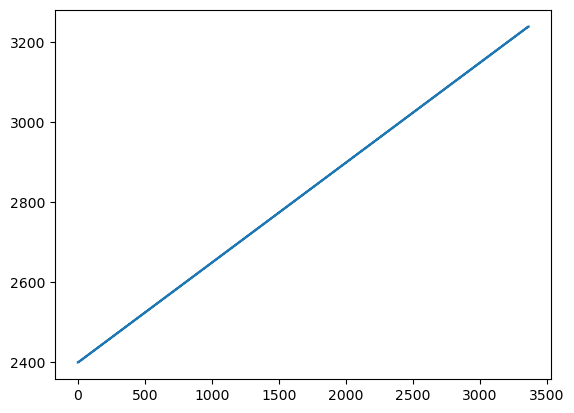

In [36]:
plt.plot(flight_data2['Frame'])

In [37]:
flight_data2['datetime'] = pd.to_datetime(flight_data2['Time'])

<ipython-input-37-1c35e62fb0b3>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight_data2['datetime'] = pd.to_datetime(flight_data2['Time'])


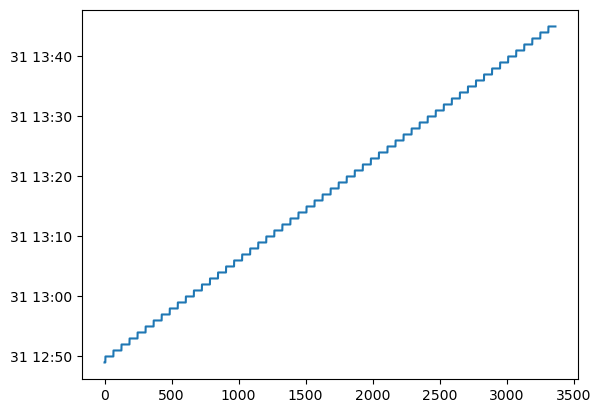

In [38]:
plt.plot(flight_data2['datetime'])

In [40]:
vibetime = np.array([a+b for a in flight_data2['seconds'] for b in [0,0.125,0.25,0.375,0.5,0.625,0.75,0.875]])

In [41]:
vibetime

array([0.000000e+00, 1.250000e-01, 2.500000e-01, ..., 3.363625e+03,
       3.363750e+03, 3.363875e+03], shape=(26912,))

In [43]:
vibrations = np.array([float(flight_data2[b].iloc[a]) for a in range(len(flight_data2)) for b in ['VRTG +0s','VRTG +0.125s','VRTG +0.25s','VRTG +0.375s','VRTG +0.5s','VRTG +0.625s','VRTG +0.75s','VRTG +0.875s']])

In [44]:
vibrations

array([0.95, 0.95, 0.95, ..., 0.95, 0.93, 0.95], shape=(26912,))

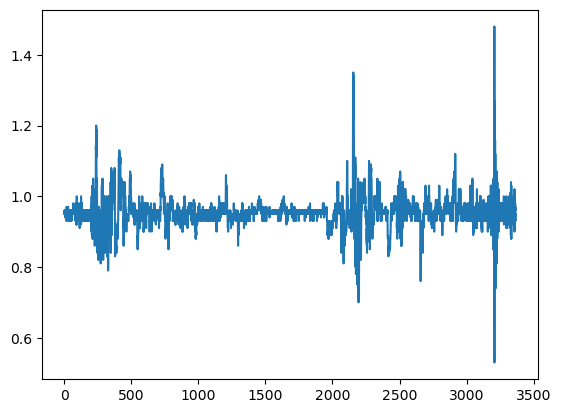

In [45]:
plt.plot(vibetime,vibrations)

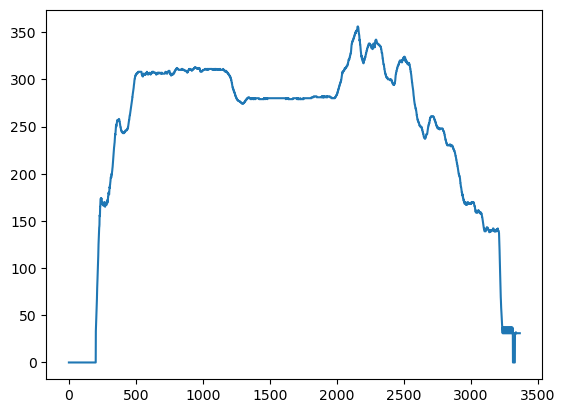

In [46]:
plt.plot(flight_data2['CAS'])

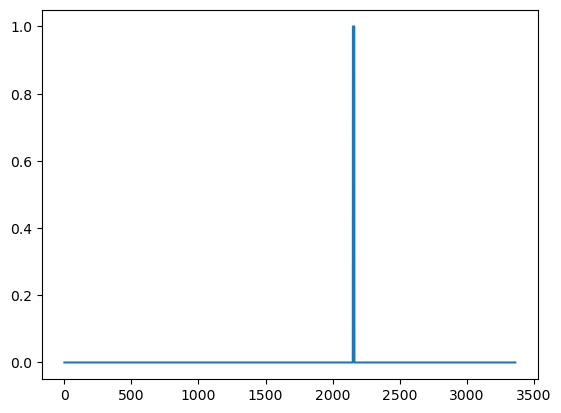

In [56]:
plt.plot([1 if a=='WARN' else 0 for a in flight_data2['VMO_MMO_OVS']] )

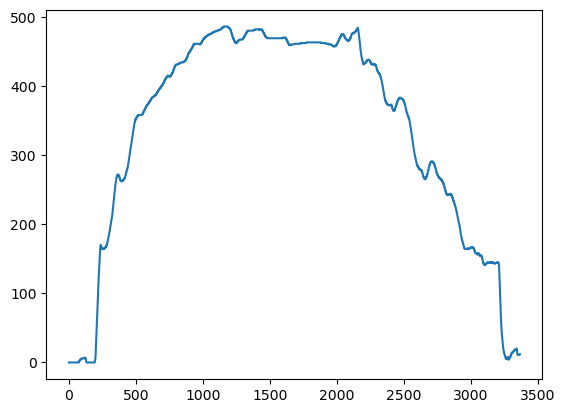

In [78]:
plt.plot(flight_data2['GS'])

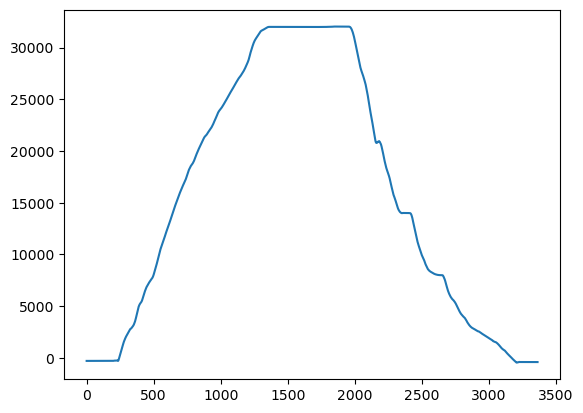

In [79]:
plt.plot(flight_data2['ALT'])

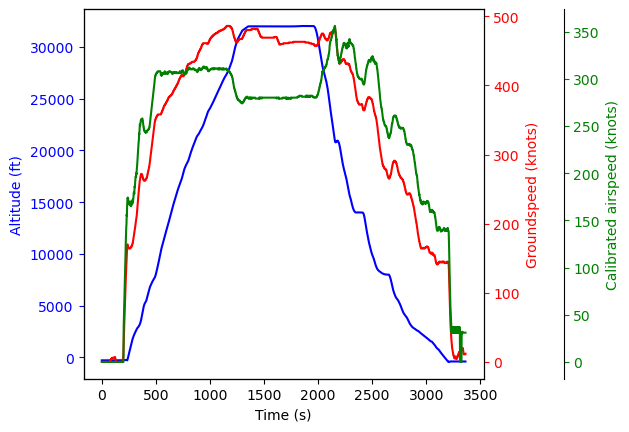

In [82]:
fig, ax = plt.subplots()
axes = [ax, ax.twinx(), ax.twinx()]
fig.subplots_adjust(right=0.75)
axes[-1].spines['right'].set_position(('axes', 1.2))
axes[0].plot(flight_data2['ALT'],c='b')
axes[0].set_ylabel('Altitude (ft)',color='b')
axes[0].set_xlabel('Time (s)')
axes[0].tick_params('y', colors='b')
axes[1].plot(flight_data2['GS'],c='r')
axes[1].set_ylabel('Groundspeed (knots)',color='r')
axes[1].tick_params('y', colors='r')
axes[2].plot(flight_data2['CAS'],c='g')
axes[2].set_ylabel('Calibrated airspeed (knots)',color='g')
axes[2].tick_params('y', colors='g')
plt.show()

In [95]:
VMOwarningdata = flight_data2[flight_data2['VMO_MMO_OVS']=='WARN']
VMOwarningdata['FDC Rate of Descent']

2152   NaN
2153   NaN
2154   NaN
2155   NaN
2156   NaN
2157   NaN
2158   NaN
2159   NaN
2160   NaN
2161   NaN
2162   NaN
Name: FDC Rate of Descent, dtype: float64

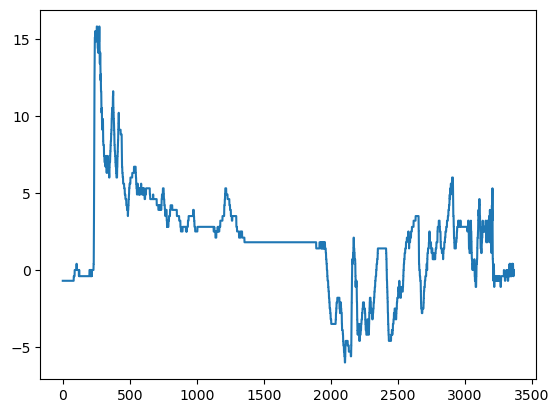

In [96]:
pitchtime = np.array([a+b for a in flight_data2['seconds'] for b in [0,0.25,0.5,0.75]])
pitch  = np.array([float(flight_data2[b].iloc[a]) for a in range(len(flight_data2)) for b in ['PITCH +0s',
                                 'PITCH +0.25s',
                                 'PITCH +0.5s',
                                 'PITCH +0.75s']])
plt.plot(pitchtime,pitch)

In [55]:
flight_data2['VMO_MMO_OVS']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
3359    NaN
3360    NaN
3361    NaN
3362    NaN
3363    NaN
Name: VMO_MMO_OVS, Length: 3364, dtype: object

In [71]:
flight_data2['LATG +0s']

0      -0.004
1      -0.004
2       0.000
3      -0.004
4      -0.004
        ...  
3359   -0.004
3360   -0.016
3361   -0.031
3362   -0.023
3363   -0.035
Name: LATG +0s, Length: 3364, dtype: float64

In [73]:

latglongtime = np.array([a+b for a in flight_data2['seconds'] for b in [0,0.25,0.5,0.75]])
longitudinal_g  = np.array([float(flight_data2[b].iloc[a]) for a in range(len(flight_data2)) for b in ['LONG +0s',
                                 'LONG +0.25s',
                                 'LONG +0.5s',
                                 'LONG +0.75s']])
lateral_g  = np.array([float(flight_data2[b].iloc[a]) for a in range(len(flight_data2)) for b in ['LATG +0s',
                                 'LATG +0.25s',
                                 'LATG +0.5s',
                                 'LATG +0.75']])

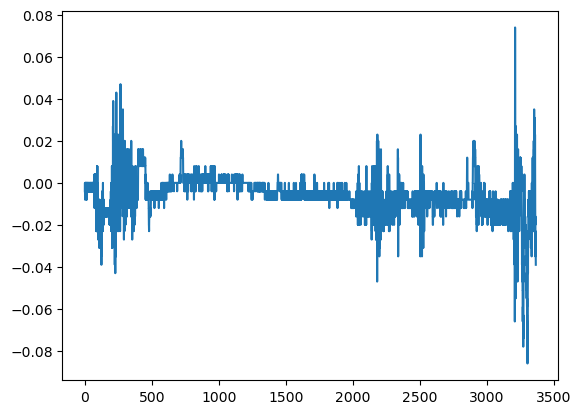

In [75]:
plt.plot(latglongtime,lateral_g)

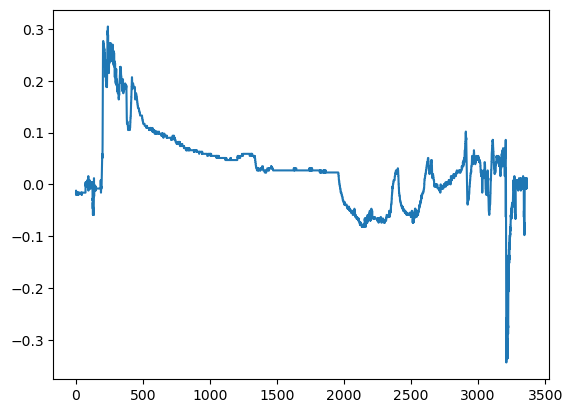

In [76]:
plt.plot(latglongtime,longitudinal_g)

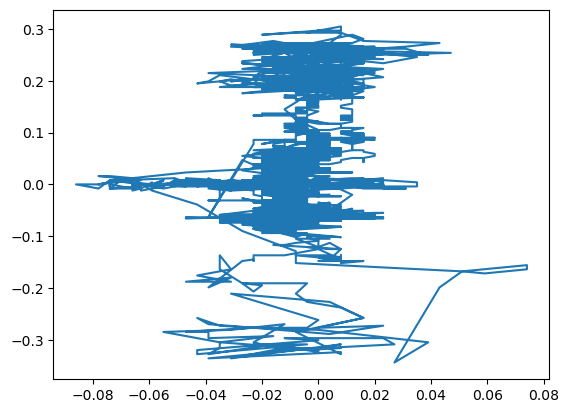

In [77]:
plt.plot(lateral_g,longitudinal_g)

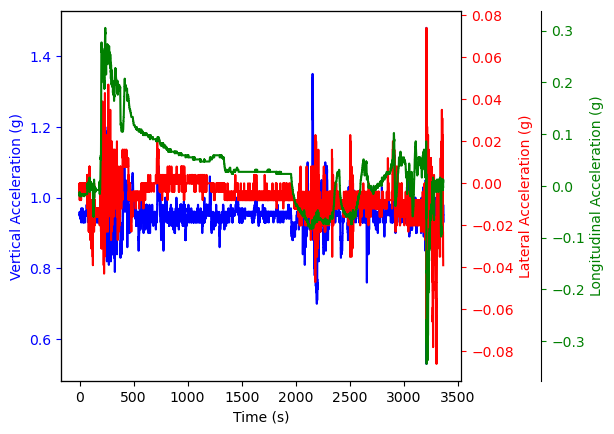

In [98]:
fig, ax = plt.subplots()
axes = [ax, ax.twinx(), ax.twinx()]
fig.subplots_adjust(right=0.75)
axes[-1].spines['right'].set_position(('axes', 1.2))
axes[0].plot(vibetime,vibrations,c='b')
axes[0].set_ylabel('Vertical Acceleration (g)',color='b')
axes[0].set_xlabel('Time (s)')
axes[0].tick_params('y', colors='b')
axes[1].plot(latglongtime,lateral_g,c='r')
axes[1].set_ylabel('Lateral Acceleration (g)',color='r')
axes[1].tick_params('y', colors='r')
axes[2].plot(latglongtime,longitudinal_g,c='g')
axes[2].set_ylabel('Longitudinal Acceleration (g)',color='g')
axes[2].tick_params('y', colors='g')
plt.show()

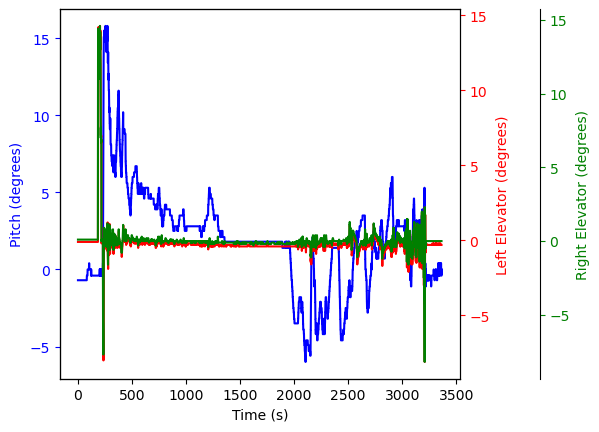

In [103]:
fig, ax = plt.subplots()
axes = [ax, ax.twinx(), ax.twinx()]
fig.subplots_adjust(right=0.75)
axes[-1].spines['right'].set_position(('axes', 1.2))
axes[0].plot(pitchtime,pitch,c='b')
axes[0].set_ylabel('Pitch (degrees)',color='b')
axes[0].set_xlabel('Time (s)')
axes[0].tick_params('y', colors='b')
axes[1].plot(flight_data2['seconds'],flight_data2['ELEV_L'],c='r')
axes[1].set_ylabel('Left Elevator (degrees)',color='r')
axes[1].tick_params('y', colors='r')
axes[2].plot(flight_data2['seconds'],flight_data2['ELEV_R'],c='g')
axes[2].set_ylabel('Right Elevator (degrees)',color='g')
axes[2].tick_params('y', colors='g')
plt.show()

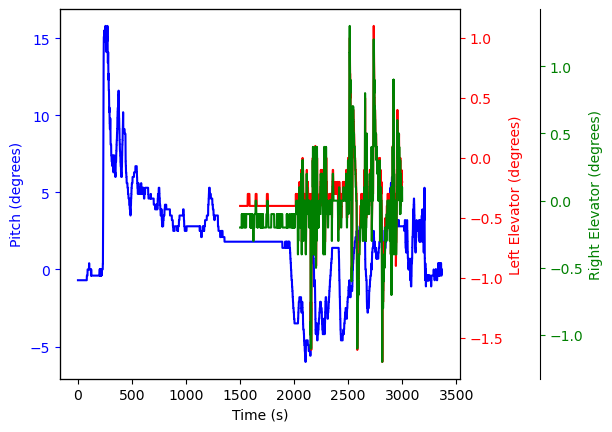

In [106]:
fig, ax = plt.subplots()
axes = [ax, ax.twinx(), ax.twinx()]
fig.subplots_adjust(right=0.75)
axes[-1].spines['right'].set_position(('axes', 1.2))
axes[0].plot(pitchtime,pitch,c='b')
axes[0].set_ylabel('Pitch (degrees)',color='b')
axes[0].set_xlabel('Time (s)')
axes[0].tick_params('y', colors='b')
axes[1].plot(flight_data2['seconds'][1500:3000],flight_data2['ELEV_L'][1500:3000],c='r')
axes[1].set_ylabel('Left Elevator (degrees)',color='r')
axes[1].tick_params('y', colors='r')
axes[2].plot(flight_data2['seconds'][1500:3000],flight_data2['ELEV_R'][1500:3000],c='g')
axes[2].set_ylabel('Right Elevator (degrees)',color='g')
axes[2].tick_params('y', colors='g')
plt.show()